In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

#Look at es

In [419]:
ALSA = pd.read_csv('../Outputs/FDN_ALSA.csv')
#ALSA.sort_values('ALSA',ascending=False).head(10)
ALSA['ALSA'].mean()


np.float64(4.897302408351307)

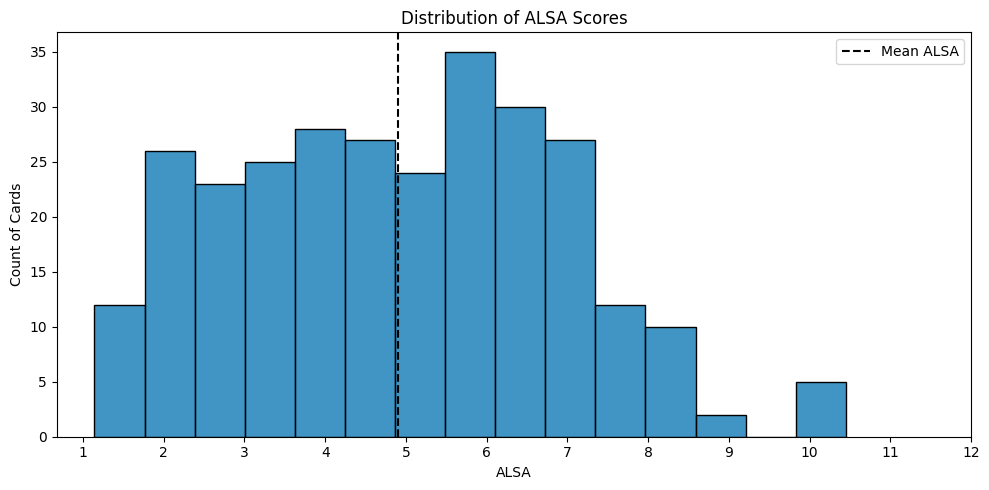

In [411]:
fig, ax = plt.subplots(figsize=(10, 5))
mean_alsa = ALSA['ALSA'].mean()
sns.histplot(data=ALSA, x='ALSA', bins=15, ax=ax, color='#0072b2')
plt.axvline(mean_alsa, color='black', linestyle='--',label = 'Mean ALSA')
ax.set_xlabel('ALSA')
ax.set_ylabel('Count of Cards')
ax.set_title('Distribution of ALSA Scores')
ax.set_xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()


In [382]:
card_df = pd.read_csv('../Inputs/FDNCardData.csv')
card_df = card_df.drop('ALSA', axis=1)

df_merged = pd.merge(card_df, ALSA[['pick', 'ALSA']], left_on='Name',right_on = 'pick' ,how='left')
df_merged = df_merged.drop('pick', axis=1)
df_merged.head()


,Name,Color,Rarity,# Seen,# Picked,ATA,# GP,% GP,GP WR,# OH,OH WR,# GD,GD WR,# GIH,GIH WR,# GNS,GNS WR,IIH,ALSA
0,Sire of Seven Deaths,NaN,M,87,80,NaN,576,97.6%,61.1%,103,NaN,140,NaN,243,NaN,328,NaN,NaN,1.141903
1,"Arahbo, the First Fang",W,R,342,205,NaN,1348,93.0%,62.9%,213,NaN,337,NaN,550,66.5%,792,60.1%,6.4pp,1.912235
2,Armasaur Guide,W,C,6983,705,11.27,701,14.1%,60.3%,113,NaN,146,NaN,259,NaN,444,NaN,NaN,7.750222
3,Cat Collector,W,U,1111,499,NaN,3122,89.4%,61.6%,490,NaN,744,64.9%,1234,64.0%,1882,60.0%,4.0pp,2.636125
4,Celestial Armor,W,R,304,213,NaN,1389,90.6%,61.9%,225,NaN,363,NaN,588,68.2%,801,57.4%,10.8pp,1.705561


In [383]:
draft_df = pd.read_csv('../Inputs/fdn_small.csv')
draft_df = pd.read_csv('/Users/jacksonlipfert/Desktop/62WinRatePremierDraft.csv', nrows=200000)
#print(set(draft_df['pick_number']))

In [384]:
#Define functions to get us mean and min ALSA for each pack

basics = ['Plains','Island','Swamp','Mountain','Forest']
pack_col_prefix = 'pack_card_'

def get_cards_in_pack(row):
    '''Get cards from row, return their name, color, and ALSA'''
    card_mask = row.filter(like='pack_card_') == 1
    cards = [col[10:] for col in card_mask[card_mask].index]
    #cards = [col[10:] for col in row.index[row == 1]]
    cards_in_pack_df = df_merged[df_merged['Name'].isin(cards) & ~df_merged['Name'].isin(basics)][['Name', 'Color', 'ALSA']]
    return cards_in_pack_df

def get_pack_color_metrics(row):
    '''Get cards from row, get card data, group by color, take the min and mean ALSA'''
    cards_in_pack_df = get_cards_in_pack(row)
    if cards_in_pack_df.empty:
        return {}
    #mins = {f'{color}_min': val for color, val in cards_in_pack_df.groupby('Color')['ALSA'].min().items()}
    means = {f'{color}_mean': val for color, val in cards_in_pack_df.groupby('Color')['ALSA'].mean().items()}
    return {**means}

#pack_1 = get_pack_color_metrics(draft_df.iloc[1])
#print(get_cards_in_pack(draft_df.iloc[1]))

In [385]:
#Create columns with ALSA for all colors (single, pairs,UBG, WUBRG, and Null), then append to draft data

color_columns = draft_df.apply(get_pack_color_metrics, axis=1, result_type='expand')
draft_df_with_ALSA = pd.concat([draft_df, color_columns], axis=1)

In [386]:
draft_df_with_ALSA.head()

,Unnamed: 0,expansion,event_type,draft_id,draft_time,rank,event_match_wins,event_match_losses,pack_number,pick_number,...,WU_mean,WB_mean,WR_mean,UG_mean,RG_mean,BR_mean,WG_mean,BG_mean,WUBRG_mean,UBG_mean
0,1512,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1513,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1514,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1515,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1516,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [387]:
#functions for determining color identity 

def get_previous_picks(row):
    '''get and return previous rows from the same draft'''
    current_pack = row['pack_number']
    current_pick = row['pick_number']
    draft = draft_df[draft_df['draft_id'] == row['draft_id']]
    
    previous_packs = draft[draft['pack_number'] < current_pack]
    current_pack_previous_picks = draft[
        (draft['pack_number'] == current_pack) & 
        (draft['pick_number'] < current_pick)
    ]
    
    return pd.concat([previous_packs, current_pack_previous_picks])

def get_color_identity(row):
    '''gets rows before given row and returns the top two colors from previously picked cards'''
    previous_picks = get_previous_picks(row)['pick']
    cards_in_pack_df = df_merged[df_merged['Name'].isin(previous_picks) & ~df_merged['Name'].isin(basics)][['Name', 'Color', 'ALSA']]
    
    colors = cards_in_pack_df['Color'].dropna().apply(list).explode()
    top_two_colors = colors.value_counts().index[:2].tolist()

    return top_two_colors
    
get_color_identity(draft_df.iloc[250])


['R', 'G']

In [388]:
def get_color_identity_for_draft(draft_df_group):
    '''get row level color identity over whole drafts, hopefully will improve performance a bit'''
    results = []
    
    for i, row in draft_df_group.iterrows():
        #loop over rows, getting current and previous picks each time
        current_pack = row['pack_number']
        current_pick = row['pick_number']
        
        previous_picks = draft_df_group[
            (draft_df_group['pack_number'] < current_pack) |
            ((draft_df_group['pack_number'] == current_pack) & (draft_df_group['pick_number'] < current_pick))
        ]['pick']
        #use the logic from the get_color_identity function to get top two colors up to current pick
        cards = df_merged[df_merged['Name'].isin(previous_picks) & ~df_merged['Name'].isin(basics)]['Color']
        colors = cards.dropna().apply(list).explode()
        top_two = colors.value_counts().index[:2].tolist()

        #append results before returning
        results.append(top_two)
    
    return results

# apply function over df but over whole drafts


In [389]:
#add color identity column to data frame
#draft_df_with_ALSA['color_identity'] = draft_df_with_ALSA.apply(get_color_identity, axis=1)

draft_df_with_ALSA['color_identity'] = draft_df.groupby('draft_id', group_keys=False).apply(
    lambda x: pd.Series(get_color_identity_for_draft(x), index=x.index)
)

/var/folders/17/1lp6v8rx7hg46v35nrbf4mk00000gn/T/ipykernel_41558/470280964.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  draft_df_with_ALSA['color_identity'] = draft_df.groupby('draft_id', group_keys=False).apply(


In [390]:
#define function to assign treatment

color_mean_ALSA_cols = set(draft_df_with_ALSA.filter(like='mean'))

def assign_treatment(row, treatment_threshold, pick_limit=100):
    '''Determines best cards in the pack, if above treatment threshold and not in current colors then instrument and if taken then treatment'''

    cards = get_cards_in_pack(row)
    pool_colors = row['color_identity']
    
    #return false if empty
    if cards.empty:
        return {'treatment': False, 'control': False}
    
    #limit treatment just to picks before pick_limit
    if row['pick_number'] >= pick_limit:
        return {'treatment': False, 'control': False}
    
    #we only want treatment drafts where we already have two colors of picks
    if len(pool_colors) < 2:
        return {'treatment': False, 'control': False}

    #Do pick asdjusted ALSA over pack, remove colorless cards, then store cards below treatment threshold as best_cards
    cards['packs_ahead_of_ALSA'] = row['pick_number']+1 - cards['ALSA']
    #best_cards = cards[(cards['PAA'] <= treatment_threshold) & (cards['Color'].notna()) & (cards['ALSA'] <= 5)]

    #limit to colored cards with ALSA in the top half
    best_cards = cards[(cards['packs_ahead_of_ALSA'] >= treatment_threshold) & (cards['Color'].notna()) & (cards['ALSA'] <= 5)]
    #print(row['pick_number'] + 1)
    

    #of best cards, check which aren't in our colors. These are our treatment cards
    best_cards['in_colors'] = best_cards['Color'].apply(lambda x: all(c in pool_colors for c in x))
    treatment_cards = best_cards[best_cards['in_colors'] == False]

    picked_treatment_card = treatment_cards['Name'].isin([row['pick']]).any()
    matches = cards.loc[cards['Name'] == row['pick'], 'Color']
    if matches.empty:
        return None
    picked_card_color = matches.iloc[0]

    #treatment is if they picked a treatment card
    treatment = picked_treatment_card
    #instrument is if they saw a treatment card but didn't take it
    control = not treatment_cards.empty and not picked_treatment_card
    
    return {'treatment': treatment, 'control': control, 'best_cards': treatment_cards['Name'],'pick_color':picked_card_color}

print(assign_treatment(draft_df_with_ALSA.iloc[4],1))

{'treatment': np.True_, 'control': False, 'best_cards': 8    Dazzling Angel
Name: Name, dtype: object, 'pick_color': 'W'}


/var/folders/17/1lp6v8rx7hg46v35nrbf4mk00000gn/T/ipykernel_41558/2227448117.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_cards['in_colors'] = best_cards['Color'].apply(lambda x: all(c in pool_colors for c in x))


In [391]:
#Add treatment to the data frame

treatment_threshold = 2

draft_df_with_ALSA[['treatment','control','best_cards','pick_color']] = draft_df_with_ALSA.apply(lambda row: assign_treatment(row,treatment_threshold), axis=1, result_type='expand')

In [392]:
#sanity check
draft_df_with_ALSA[draft_df_with_ALSA['control'] == True][['pick','best_cards','color_identity','treatment','control','pick_color']]

,pick,best_cards,color_identity,treatment,control,pick_color
7,Apothecary Stomper,"47 Refute Name: Name, dtype: object","[W, G]",False,True,G
20,Burnished Hart,"238 Empyrean Eagle Name: Name, dtype: object","[G, W]",False,True,NaN
22,Hare Apparent,"171 Eaten Alive Name: Name, dtype: object","[W, G]",False,True,W
23,Meteor Golem,"164 Think Twice Name: Name, dtype: object","[W, G]",False,True,NaN
34,Fishing Pole,"47 Refute Name: Name, dtype: object","[G, W]",False,True,NaN
...,...,...,...,...,...,...
199901,Cephalid Inkmage,"240 Heroic Reinforcements Name: Name, dtype...","[W, U]",False,True,U
199902,Thousand-Year Storm,"240 Heroic Reinforcements Name: Name, dtype...","[W, U]",False,True,UR
199914,Elementalist Adept,"197 Flamewake Phoenix Name: Name, dtype: ob...","[W, U]",False,True,U
199929,Resolute Reinforcements,"68 Seeker's Folly Name: Name, dtype: object","[W, U]",False,True,W


In [393]:
draft_df_with_ALSA.head()


,Unnamed: 0,expansion,event_type,draft_id,draft_time,rank,event_match_wins,event_match_losses,pack_number,pick_number,...,BR_mean,WG_mean,BG_mean,WUBRG_mean,UBG_mean,color_identity,treatment,control,best_cards,pick_color
0,1512,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,0,...,NaN,NaN,NaN,NaN,NaN,[],False,False,NaN,NaN
1,1513,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,1,...,NaN,NaN,NaN,NaN,NaN,[G],False,False,NaN,NaN
2,1514,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,2,...,NaN,NaN,NaN,NaN,NaN,[G],False,False,NaN,NaN
3,1515,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,3,...,NaN,NaN,NaN,NaN,NaN,"[G, U]",False,False,"Series([], Name: Name, dtype: object)",W
4,1516,FDN,PremierDraft,ca9c82901d6844109a9fae4726b5d99f,2024-11-12 22:02:55,platinum,1,3,0,4,...,NaN,NaN,NaN,NaN,NaN,"[G, U]",False,False,"Series([], Name: Name, dtype: object)",W


In [394]:
feature_suffixes = ('_mean','_var')
win_cols = ['event_match_wins','event_match_losses']

# grab mean ALSA columns
cols = [col for col in draft_df_with_ALSA.columns if col.endswith('_mean')]

#group by draft id, then get ALSA columns, then take the variance, return as a dataframe
var_cols = draft_df_with_ALSA.groupby('draft_id')[cols].var()
var_cols = var_cols.add_suffix('_var')

#features
feature_cols = [col for col in draft_df_with_ALSA.columns if col.endswith(feature_suffixes)]
feature_cols = ['W_mean','U_mean','B_mean','R_mean','G_mean']


In [395]:
color_list = ['W','U','B','R','G']
color_one_hot_names = ['W_id','U_id','B_id','R_id','G_id']

def get_color_identity_match(row):
    color_identity = row['color_identity']

    colors = {x: 1 if x in color_identity else 0 for x in color_list}

    return colors


In [396]:
small_treatment_df = draft_df_with_ALSA[['draft_id','treatment','control','pack_number','pick_number','color_identity'] + feature_cols + win_cols]
#small_treatment_df = pd.merge(small_treatment_df, var_cols, on='draft_id')
#small_treatment_df.to_csv('../Outputs/pre_matching_df.csv')

small_treatment_df[color_one_hot_names] = small_treatment_df.apply(get_color_identity_match, axis=1, result_type='expand')

pre_matching_df = small_treatment_df.query('control or treatment')

#pre_matching_df.to_csv('../Outputs/pre_matching_df.csv')
pre_matching_df.to_csv('../Results/pre_matching_df_T2_62WR.csv')


/var/folders/17/1lp6v8rx7hg46v35nrbf4mk00000gn/T/ipykernel_41558/2246435082.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_treatment_df[color_one_hot_names] = small_treatment_df.apply(get_color_identity_match, axis=1, result_type='expand')
/var/folders/17/1lp6v8rx7hg46v35nrbf4mk00000gn/T/ipykernel_41558/2246435082.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_treatment_df[color_one_hot_names] = small_treatment_df.apply(get_color_identity_match, axis=1, result_type='expand')
/var/folde

In [397]:
#It may be worth looking at the whole draft but also just until the treatment pick

feature_cols = feature_cols

#set treatment pack and pick
treat_pack = 1
treat_pick = 5

#get treatment and instrument rows, save the draft ids to join on after matching
#treatment_df = draft_df_with_ALSA.query('pack_number == @treat_pack and pick_number == @treat_pick and treatment')
#control_df = draft_df_with_ALSA.query('pack_number == @treat_pack and pick_number == @treat_pick and control')

treatment_df = small_treatment_df.query('pack_number == @treat_pack and pick_number == @treat_pick and treatment')
control_df = small_treatment_df.query('pack_number == @treat_pack and pick_number == @treat_pick and control')

treatment_draft_ids = list(set(treatment_df['draft_id']))
control_draft_ids = list(set(control_df['draft_id']))

print(treatment_df.head())

#print(draft_df_with_ALSA['draft_id'].nunique())
#print(treat_df['draft_id'].nunique())
#print(treat_and_instrument_df['draft_id'].nunique())
#print(control_df['draft_id'].nunique())

                              draft_id treatment control  pack_number  \
1664  bc5e332bbab54025a28f6f3872f870a2      True   False            1   
4940  a3bcfbddff004468ab019f945e9adee3      True   False            1   
5612  c8a32322faf84af0bf9c4b984a90251a      True   False            1   
5822  99d4098f757b4012a15df550e8c9b979      True   False            1   
6158  7c689f6440004e36a7d8cddac8bb84ad      True   False            1   

      pick_number color_identity    W_mean    U_mean    B_mean    R_mean  \
1664            5         [B, W]  5.739389  2.469713  8.299559  8.575703   
4940            5         [G, W]       NaN  3.929155  6.793851  5.130062   
5612            5         [U, B]  5.469672       NaN  6.154293  5.210100   
5822            5         [G, U]  6.066453  5.572787       NaN  4.661088   
6158            5         [U, R]  5.742450  6.517059  8.299559  4.229867   

        G_mean  event_match_wins  event_match_losses  W_id  U_id  B_id  R_id  \
1664  7.005859          

In [398]:
scaler = StandardScaler()

#this part seems to be a problem, it gives artifically low values for picks without data
treatment_df_no_na = treatment_df.fillna(12)
control_df_no_na = control_df.fillna(12)


#reduce the dfs down to treatment, instrument, and feature columns, then group by draft ID and take the mean of features
treatment_df_grouped = treatment_df_no_na[['draft_id'] + feature_cols +color_one_hot_names+ win_cols].groupby('draft_id').mean()
control_df_grouped = control_df_no_na[['draft_id'] + feature_cols +color_one_hot_names + win_cols].groupby('draft_id').mean()


#join variance columns on draft ID to treatment and control
treatment_df_grouped_var = pd.merge(treatment_df_grouped, var_cols, on='draft_id')
control_df_grouped_var = pd.merge(control_df_grouped, var_cols, on='draft_id')

treatment_df_grouped_var.fillna(0,inplace=True)
control_df_grouped_var.fillna(0,inplace=True)

#print(control_df_grouped_var.columns)

#scale control and treatment
control_scaled = scaler.fit_transform(control_df_grouped_var[feature_cols])
treatment_scaled = scaler.transform(treatment_df_grouped_var[feature_cols])

#find nearest neighbor of treatment row
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_scaled)
distances, indices = nn.kneighbors(treatment_scaled, n_neighbors=1)

matched_indices = indices.flatten()
matched_control = control_df_grouped_var.iloc[matched_indices].copy()

print(matched_control.shape)

/var/folders/17/1lp6v8rx7hg46v35nrbf4mk00000gn/T/ipykernel_41558/297927270.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  treatment_df_no_na = treatment_df.fillna(12)
/var/folders/17/1lp6v8rx7hg46v35nrbf4mk00000gn/T/ipykernel_41558/297927270.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  control_df_no_na = control_df.fillna(12)


(188, 29)


In [399]:
#might have an issue here since we changed the definition of treatment and instrument


treatment_df_grouped_var['treatment'] = 1

matched_control['treatment'] = 0

matched_df = pd.concat([treatment_df_grouped_var, matched_control])


#matched_df[['treatment','instrument']].value_counts()
print(matched_df.head())
#matched_df['WR_mean']

                                     W_mean    U_mean     B_mean    R_mean  \
draft_id                                                                     
009d3c838eb64498a34307290bb25963   4.928469  8.396405   4.176257  6.439153   
0285900b50e64e8d8b717a8b627253e0  12.000000  4.285555   3.167478  7.479489   
065d440c7285446cbea554dfc6725c16   5.363389  4.763728  12.000000  6.088454   
06e36837cda14053b230b297680819c2   3.357101  4.784923   6.793851  7.510956   
0735b3bb5a334394ae8007c3fdcf3933   4.670725  8.396405   7.294059  7.095836   

                                     G_mean  W_id  U_id  B_id  R_id  G_id  \
draft_id                                                                    
009d3c838eb64498a34307290bb25963  12.000000   0.0   0.0   1.0   1.0   0.0   
0285900b50e64e8d8b717a8b627253e0   6.062180   1.0   1.0   0.0   0.0   0.0   
065d440c7285446cbea554dfc6725c16   7.025425   1.0   0.0   0.0   1.0   0.0   
06e36837cda14053b230b297680819c2   6.690090   0.0   0.0   1.0   1.0 

In [400]:
#do smd before matching

def stndmeandif(feature, treatment, control):
    treated_mean = treatment[feature].mean()
    control_mean = control[feature].mean()
    pooled_std = np.sqrt((treatment[feature].std()**2 + control[feature].std()**2) / 2)
    return((treated_mean - control_mean) / pooled_std)

print(stndmeandif('B_mean', treatment_df_grouped_var, control_df_grouped_var))

#print(treatment_df.shape)

0.13877620164391438


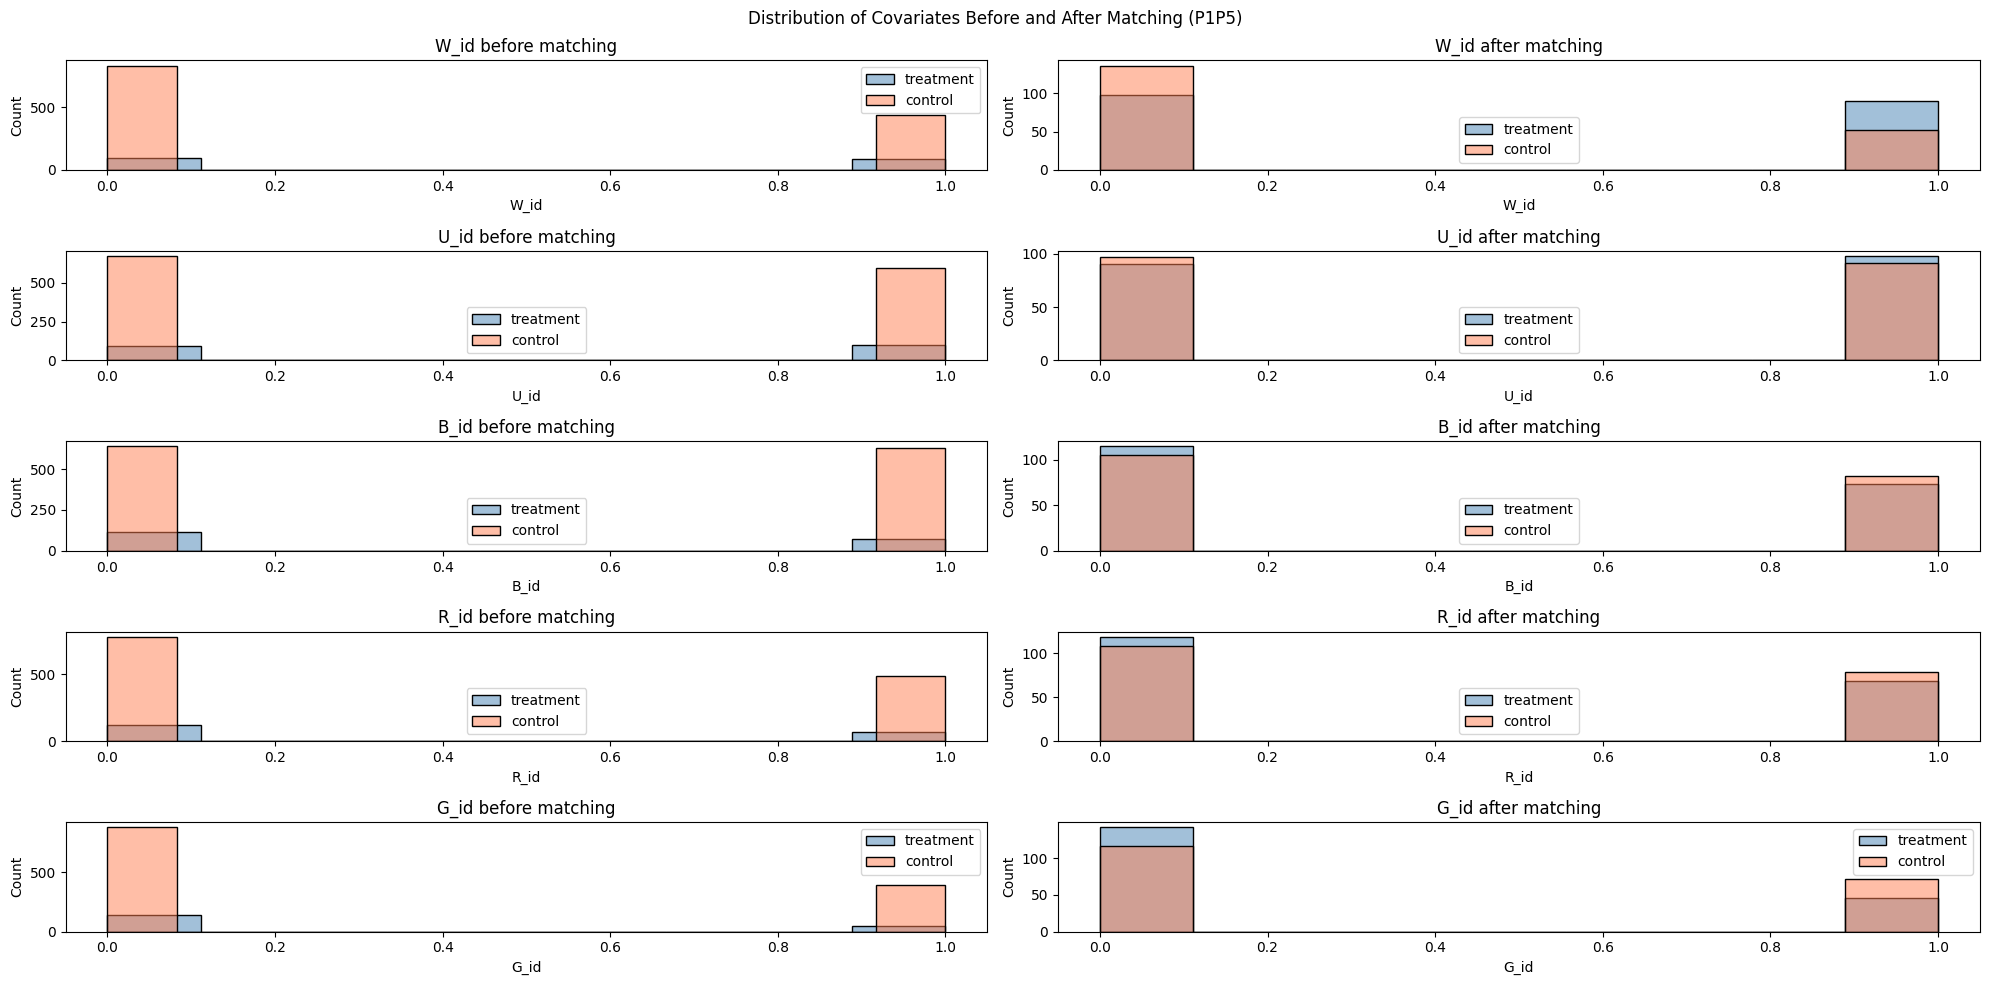

In [401]:
#Plot unbalanced covariates after matching

covariates_mean = ['W_mean','U_mean','B_mean','R_mean','G_mean']
covariates_min = ['W_min','U_min','B_min','R_min','G_min']
covariates_mean_var = ['W_mean_var','U_mean_var','B_mean_var','R_mean_var','G_mean_var']



fig, axs = plt.subplots(5, 2, figsize=(20, 10))
fig.suptitle('Distribution of Covariates Before and After Matching (P1P5)')

for i, item in enumerate(color_one_hot_names):
    # before matching
    axs[i, 0].set_title(f'{item} before matching')
    sns.histplot(data=treatment_df_grouped_var[item], label='treatment', color='steelblue', ax=axs[i, 0], alpha=0.5)
    sns.histplot(data=control_df_grouped_var[item], label='control', color='coral', ax=axs[i, 0], alpha=0.5)
    axs[i, 0].legend()

    
    # after matching
    axs[i, 1].set_title(f'{item} after matching')
    #sns.kdeplot(data=matched_df[matched_df['treatment'] == 1][item], fill=True, label='treatment', color='steelblue', ax=axs[i, 1])
    #sns.kdeplot(data=matched_df[matched_df['treatment'] == 0][item], fill=True, label='control', color='coral', ax=axs[i, 1])
    sns.histplot(data=matched_df[matched_df['treatment'] == 1][item], label='treatment', color='steelblue', ax=axs[i, 1], alpha=0.5)
    sns.histplot(data=matched_df[matched_df['treatment'] == 0][item], label='control', color='coral', ax=axs[i, 1], alpha=0.5)
    
    axs[i, 1].legend()
    

plt.tight_layout()
plt.show()
    

In [402]:
print(f'treatment mean wins: {matched_df[matched_df['treatment'] == 1]['event_match_wins'].mean()}')
print(f'control mean wins:{matched_df[matched_df['treatment'] == 0]['event_match_wins'].mean()}')


treatment mean wins: 3.2872340425531914
control mean wins:3.771276595744681
